In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [3]:
data_str = 'vin_pax_zyx_act_wholecell'
pro_str = 'pax_wholecell_norm_correctloader'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 32
latent_dim_array = [4,6,8,10,12,14,16,18,20,22,24]
latent_dim_array = [8,12,24]
BN_flag = True
dropout_flag = True
epochs = int(10000)
lr = 1e-4
eps = 3
min_samples = 5
kmeans_num_clusters = 6
loss_norm_flag = 1

dir_list = [
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_0948',
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_1005',    
]




In [4]:

transform = transforms.Compose([transforms.ToTensor()])

datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)



/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/dataset.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


In [5]:
total_sum_sq = 0.0
total_sum = 0.0
n_total = 0

for images, _ in whole_data_loader:
    images = images.to(torch.float32)
    total_sum += (images).sum().item()
    total_sum_sq += (images ** 2).sum().item()
    n_total += images.numel()

mean_square = total_sum_sq / n_total
mean = total_sum / n_total
print("Mean square of all pixels:", mean_square)

joblib.dump(mean_square,'../results/pax_wholecell_mean_square.pkl')

Mean square of all pixels: 0.06021904780085038


['../results/pax_wholecell_mean_square.pkl']

Epoch 200/10000, Train Loss: 0.1414, Val Loss: 0.1473
Epoch 400/10000, Train Loss: 0.1332, Val Loss: 0.1532
Epoch 600/10000, Train Loss: 0.1275, Val Loss: 0.1571
Epoch 800/10000, Train Loss: 0.1230, Val Loss: 0.1609
Epoch 1000/10000, Train Loss: 0.1198, Val Loss: 0.1630
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0000, max: 0.9539, mean: 0.1781, std: 0.1433
Epoch 1200/10000, Train Loss: 0.1177, Val Loss: 0.1646
Epoch 1400/10000, Train Loss: 0.1159, Val Loss: 0.1665
Epoch 1600/10000, Train Loss: 0.1141, Val Loss: 0.1674
Epoch 1800/10000, Train Loss: 0.1130, Val Loss: 0.1684
Epoch 2000/10000, Train Loss: 0.1122, Val Loss: 0.1688
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0001, max: 0.9488, mean: 0.1793, std: 0.1425
Epoch 2200/10000, Train Loss: 0.1111, Val Loss: 0.1703
Epoch 2400/10000, Train Loss: 0.1107, Val Loss: 0.1703
Epoch 2600/10000, Train Loss: 0.1100, Val Loss: 0.1707
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.1265, Val Loss: 0.1335
Epoch 400/10000, Train Loss: 0.1173, Val Loss: 0.1392
Epoch 600/10000, Train Loss: 0.1103, Val Loss: 0.1434
Epoch 800/10000, Train Loss: 0.1065, Val Loss: 0.1466
Epoch 1000/10000, Train Loss: 0.1040, Val Loss: 0.1479
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0004, max: 0.9378, mean: 0.1809, std: 0.1460
Epoch 1200/10000, Train Loss: 0.1021, Val Loss: 0.1495
Epoch 1400/10000, Train Loss: 0.1003, Val Loss: 0.1506
Epoch 1600/10000, Train Loss: 0.0997, Val Loss: 0.1516
Epoch 1800/10000, Train Loss: 0.0983, Val Loss: 0.1520
Epoch 2000/10000, Train Loss: 0.0975, Val Loss: 0.1532
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0003, max: 0.9347, mean: 0.1801, std: 0.1426
Epoch 2200/10000, Train Loss: 0.0969, Val Loss: 0.1533
Epoch 2400/10000, Train Loss: 0.0961, Val Loss: 0.1541
Epoch 2600/10000, Train Loss: 0.0959, Val Loss: 0.1540
Epoch 2

/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/autoencoders.py:97: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))


Epoch 5200/10000, Train Loss: 0.0926, Val Loss: 0.1576
Epoch 5400/10000, Train Loss: 0.0925, Val Loss: 0.1573
Epoch 5600/10000, Train Loss: 0.0924, Val Loss: 0.1574
Epoch 5800/10000, Train Loss: 0.0924, Val Loss: 0.1575
Epoch 6000/10000, Train Loss: 0.0919, Val Loss: 0.1579
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0002, max: 0.9105, mean: 0.1786, std: 0.1400
Epoch 6200/10000, Train Loss: 0.0920, Val Loss: 0.1581
Epoch 6400/10000, Train Loss: 0.0923, Val Loss: 0.1585
Epoch 6600/10000, Train Loss: 0.0917, Val Loss: 0.1583
Epoch 6800/10000, Train Loss: 0.0916, Val Loss: 0.1585
Epoch 7000/10000, Train Loss: 0.0914, Val Loss: 0.1586
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0001, max: 0.9292, mean: 0.1795, std: 0.1400
Epoch 7200/10000, Train Loss: 0.0913, Val Loss: 0.1587
Epoch 7400/10000, Train Loss: 0.0913, Val Loss: 0.1584
Epoch 7600/10000, Train Loss: 0.0913, Val Loss: 0.1589
Epo

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.1046, Val Loss: 0.1081
Epoch 400/10000, Train Loss: 0.0949, Val Loss: 0.1127
Epoch 600/10000, Train Loss: 0.0910, Val Loss: 0.1154
Epoch 800/10000, Train Loss: 0.0884, Val Loss: 0.1183
Epoch 1000/10000, Train Loss: 0.0862, Val Loss: 0.1197
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0004, max: 0.9365, mean: 0.1783, std: 0.1484
Epoch 1200/10000, Train Loss: 0.0848, Val Loss: 0.1204
Epoch 1400/10000, Train Loss: 0.0844, Val Loss: 0.1207
Epoch 1600/10000, Train Loss: 0.0836, Val Loss: 0.1212
Epoch 1800/10000, Train Loss: 0.0827, Val Loss: 0.1224
Epoch 2000/10000, Train Loss: 0.0823, Val Loss: 0.1224
Input stats — min: 0.0000, max: 0.9486, mean: 0.1818, std: 0.1731
Reconstruction stats — min: 0.0001, max: 0.9334, mean: 0.1790, std: 0.1481
Epoch 2200/10000, Train Loss: 0.0819, Val Loss: 0.1230
Epoch 2400/10000, Train Loss: 0.0815, Val Loss: 0.1234
Epoch 2600/10000, Train Loss: 0.0810, Val Loss: 0.1234
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


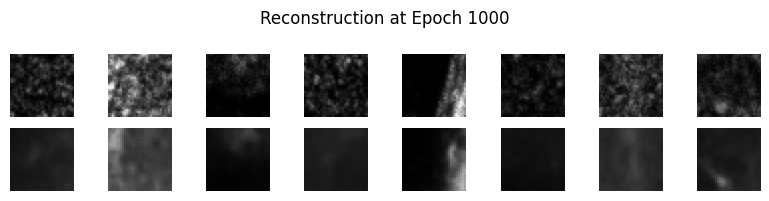

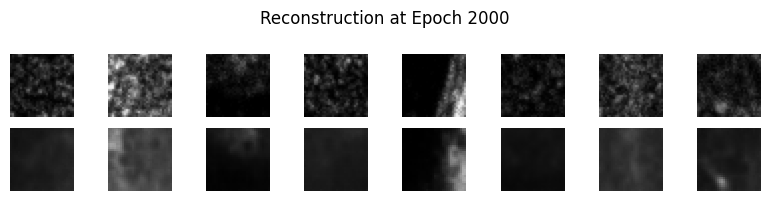

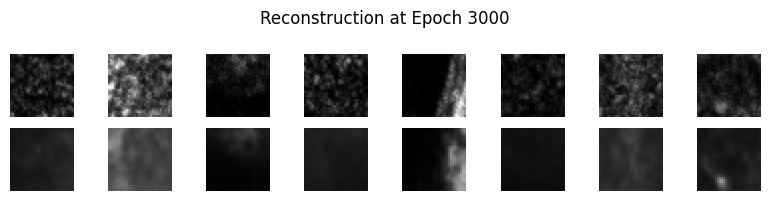

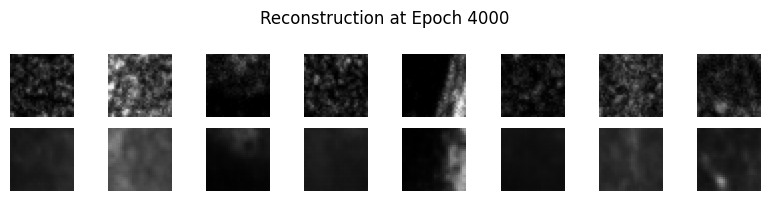

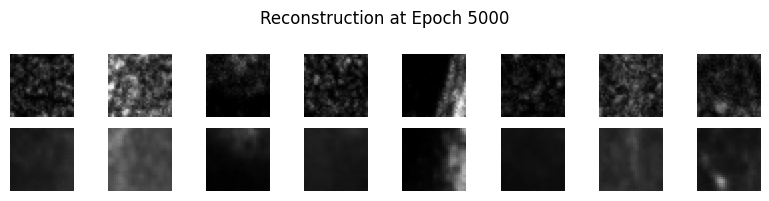

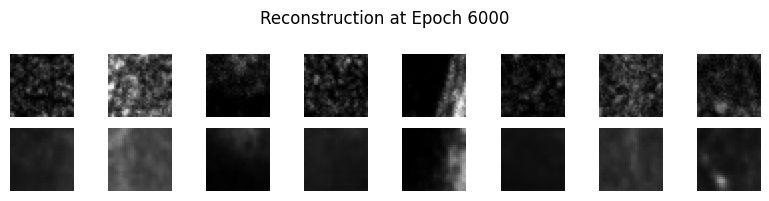

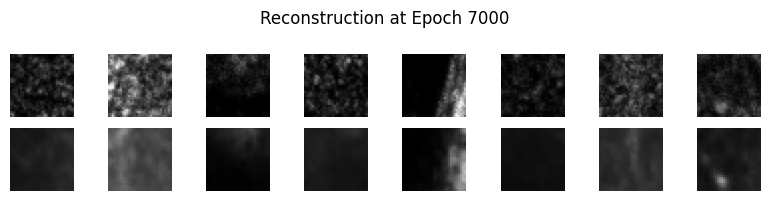

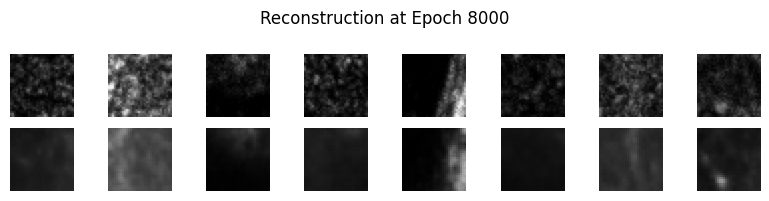

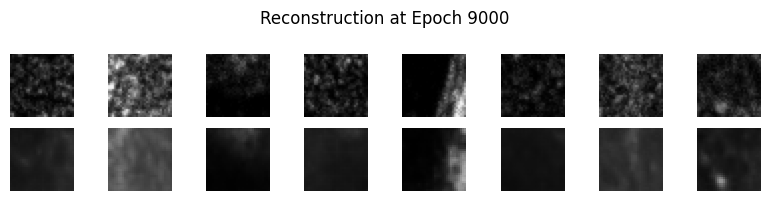

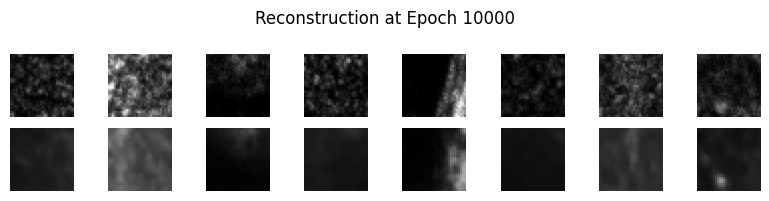

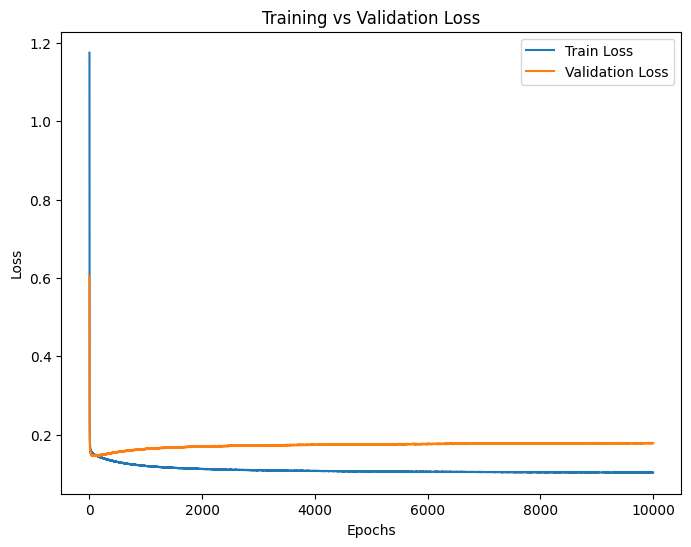

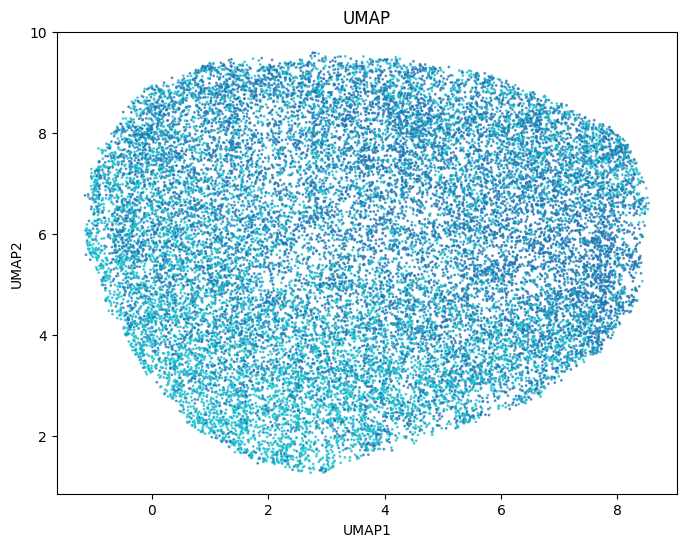

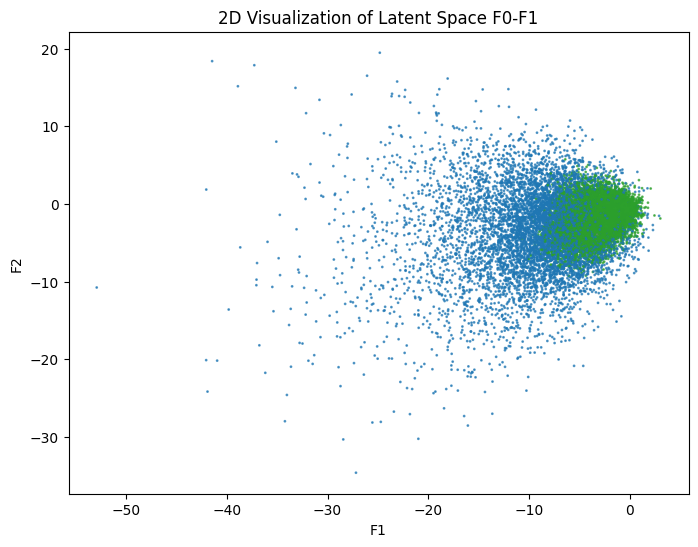

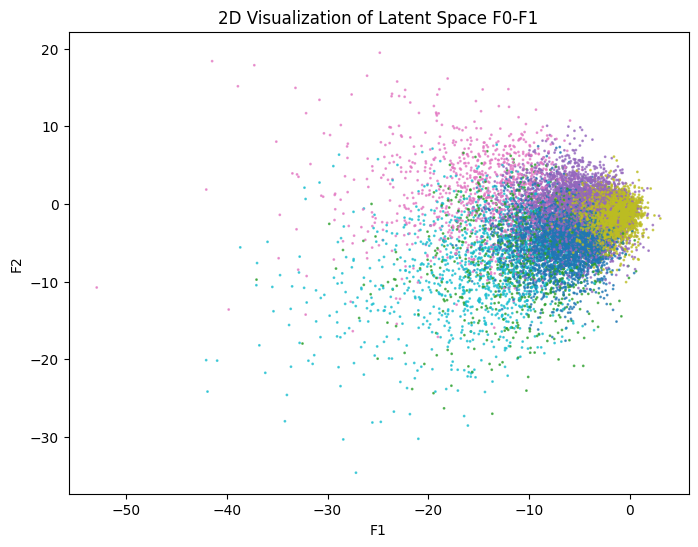

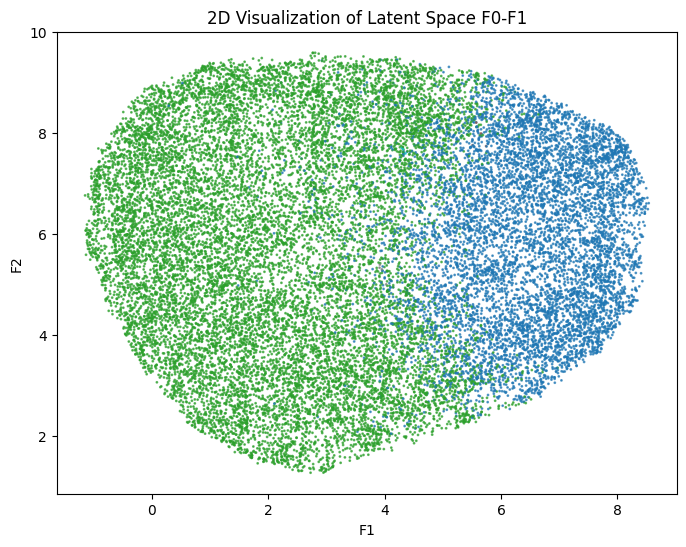

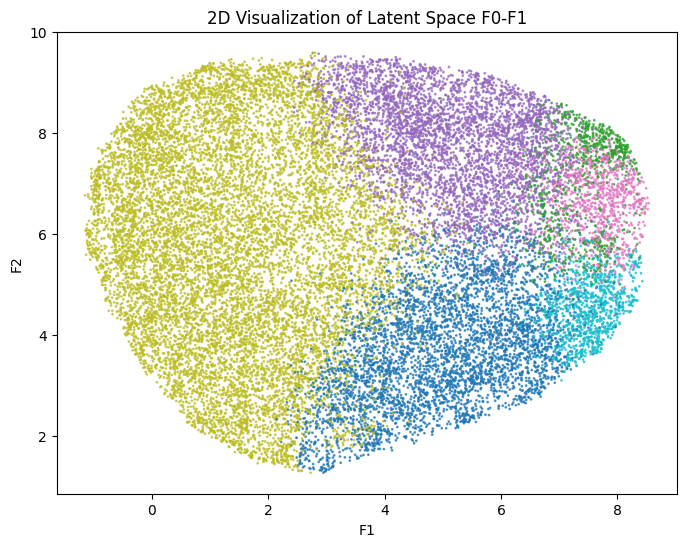

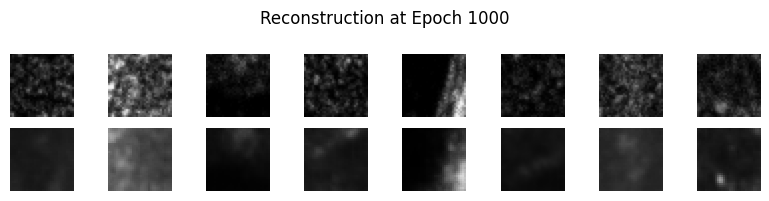

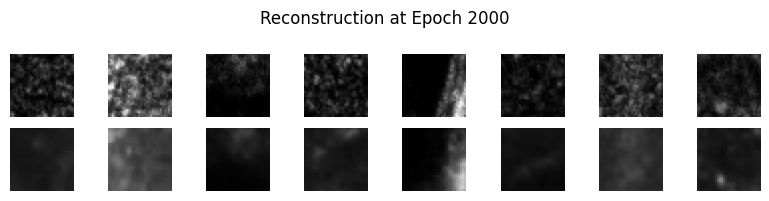

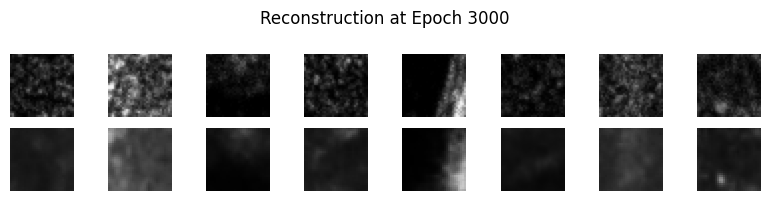

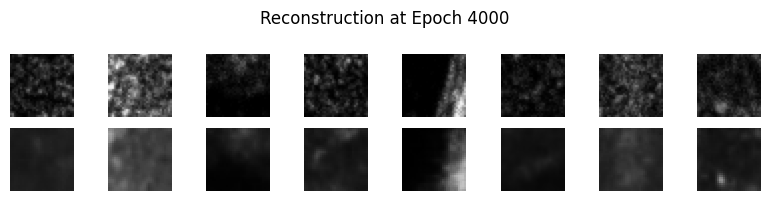

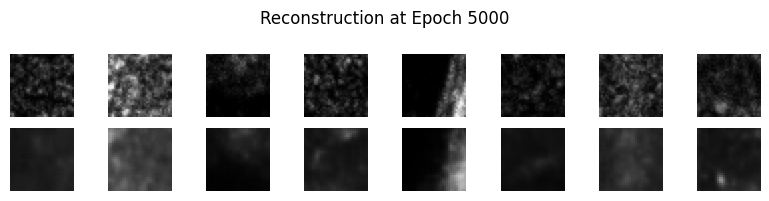

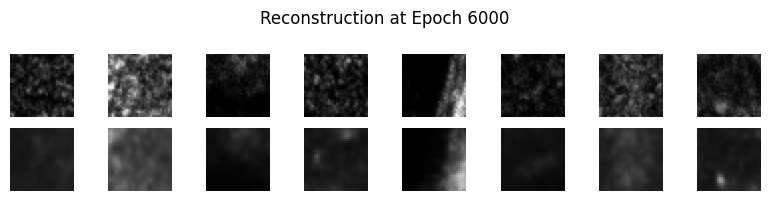

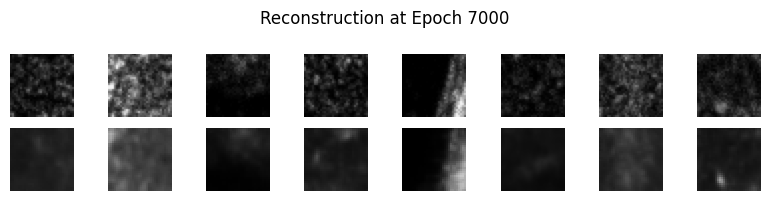

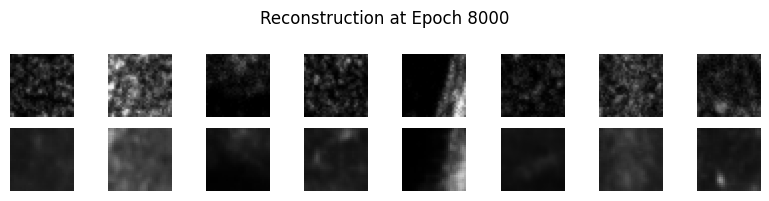

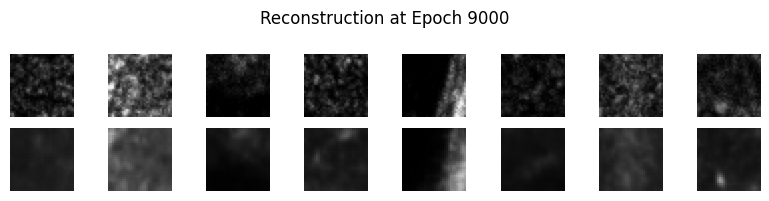

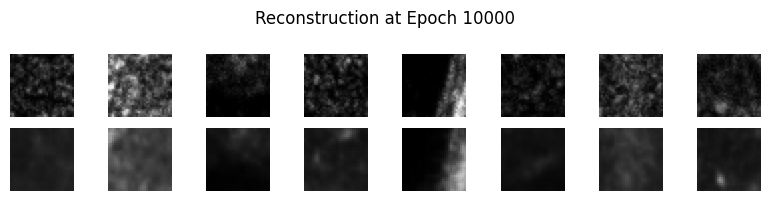

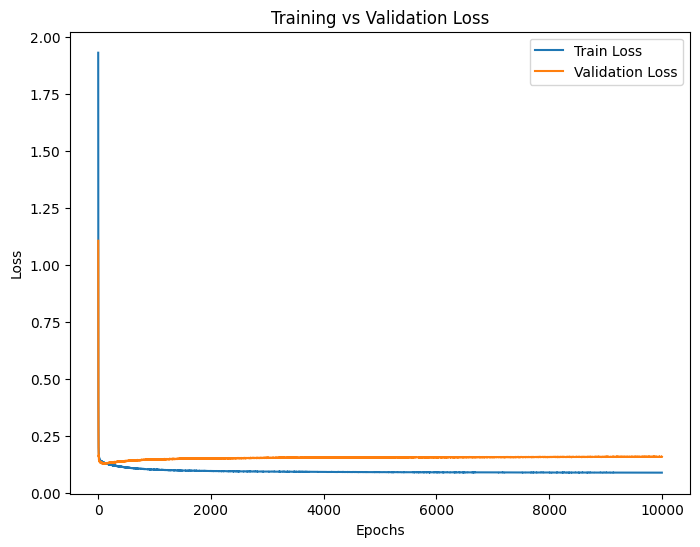

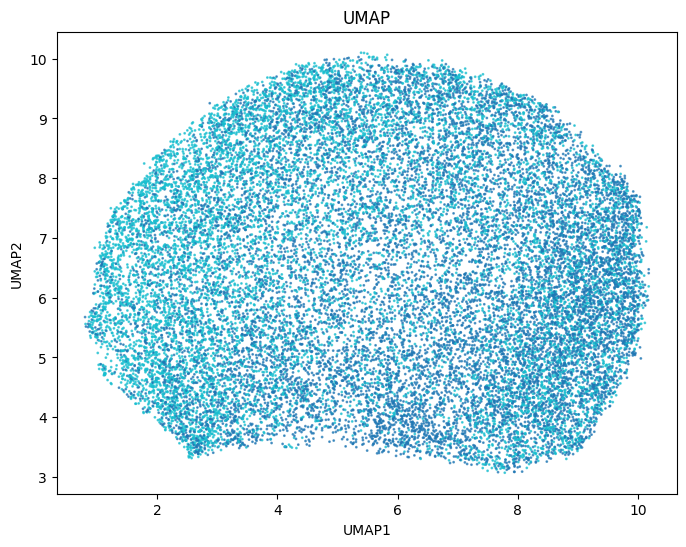

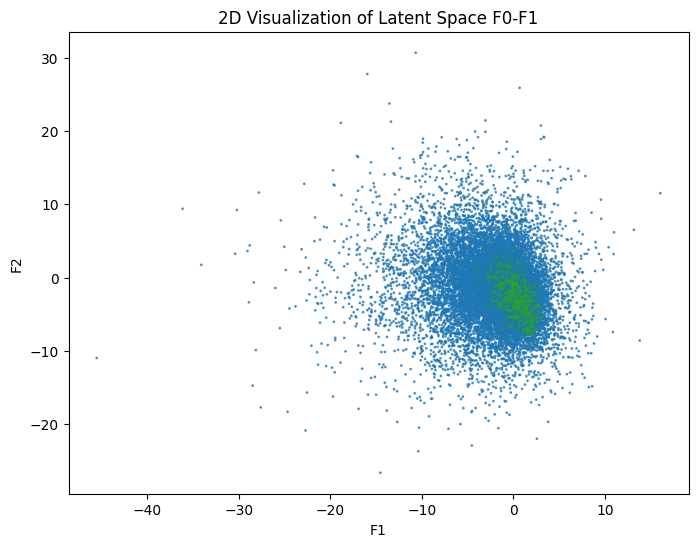

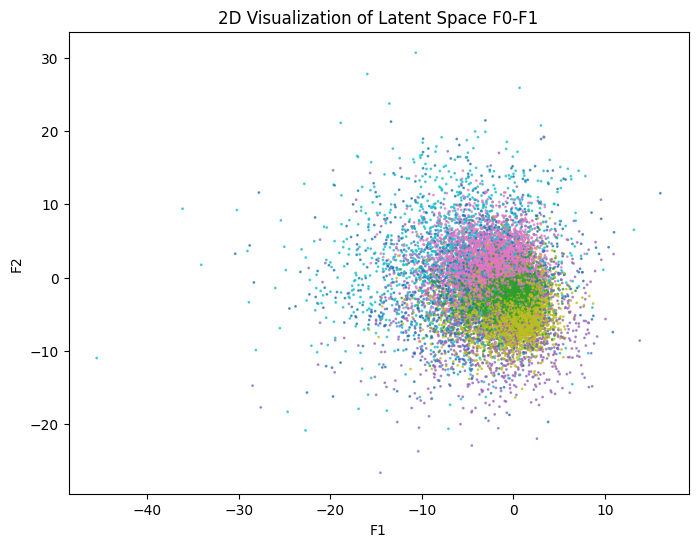

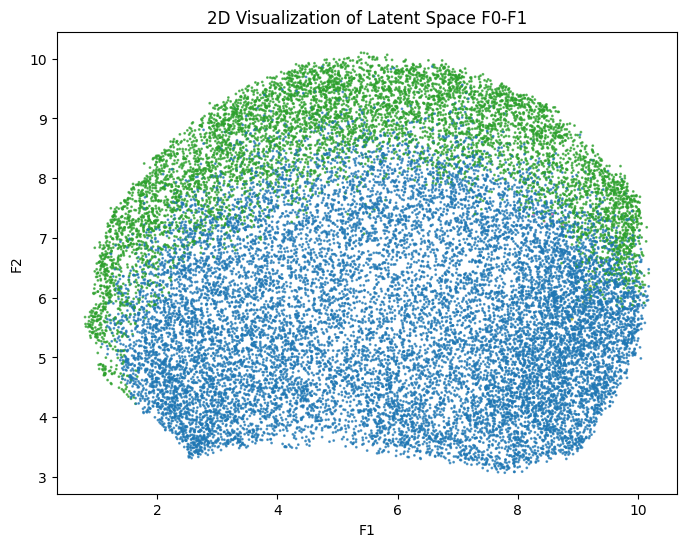

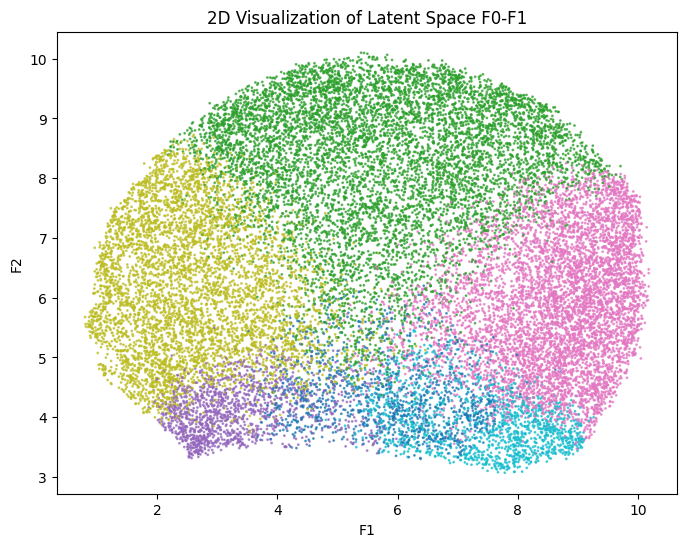

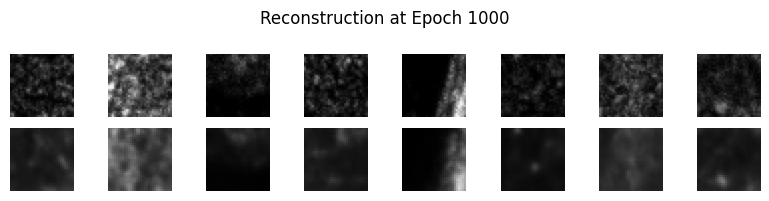

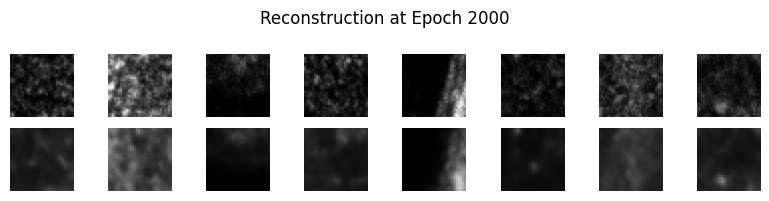

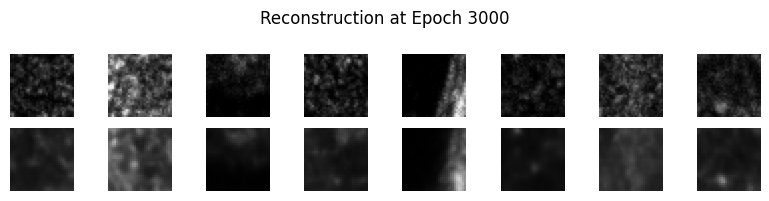

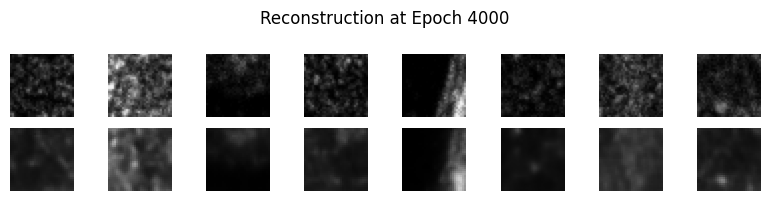

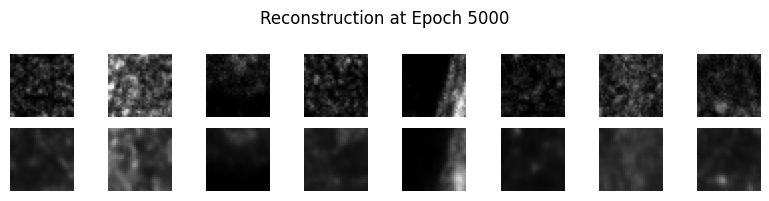

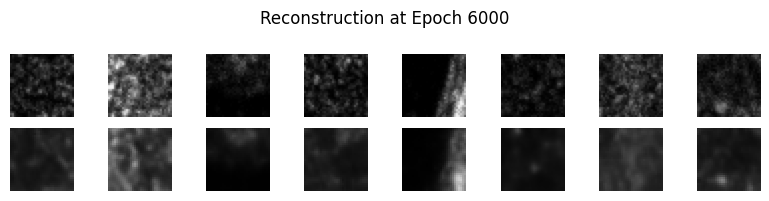

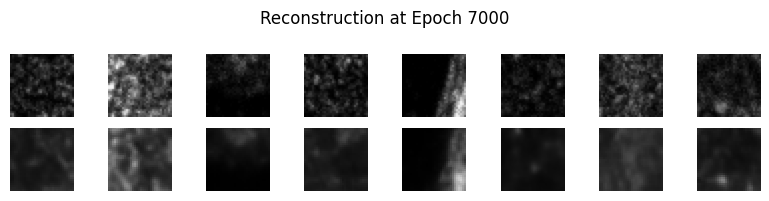

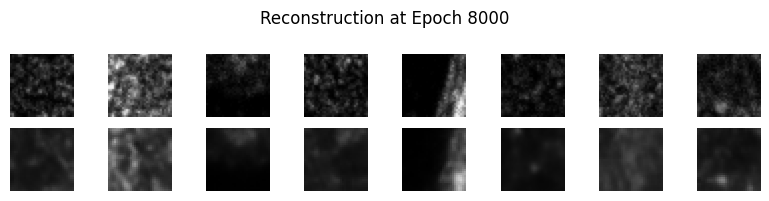

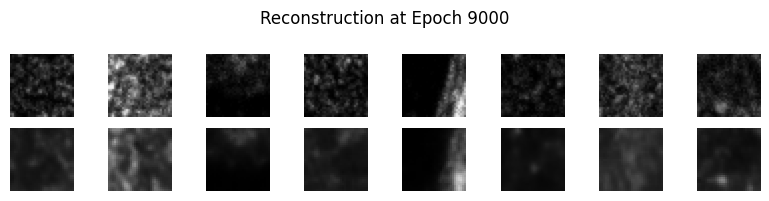

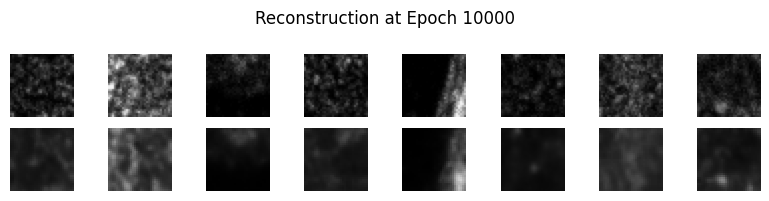

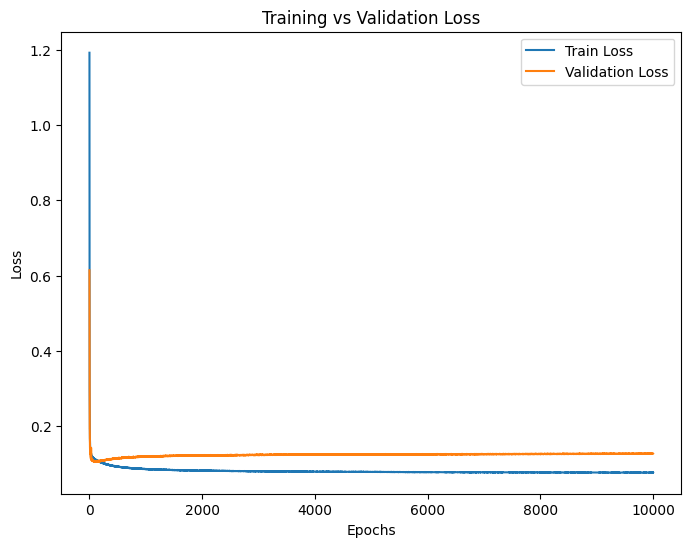

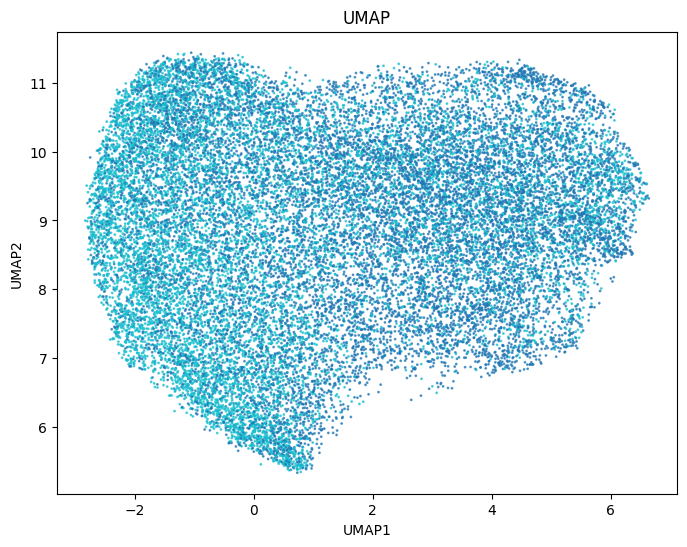

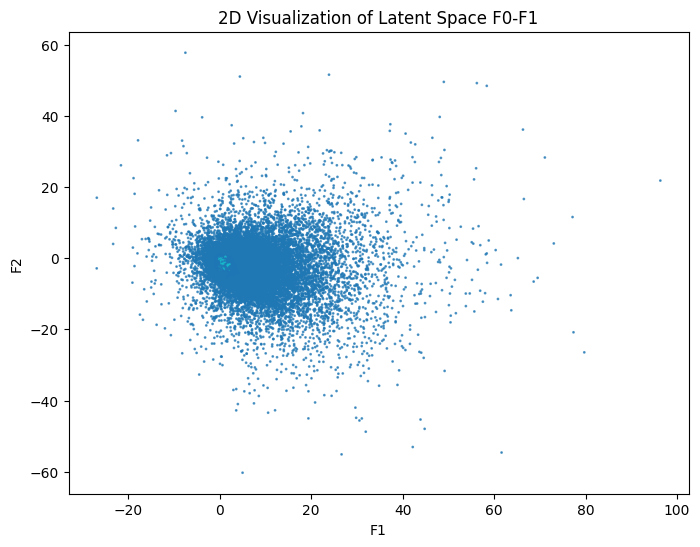

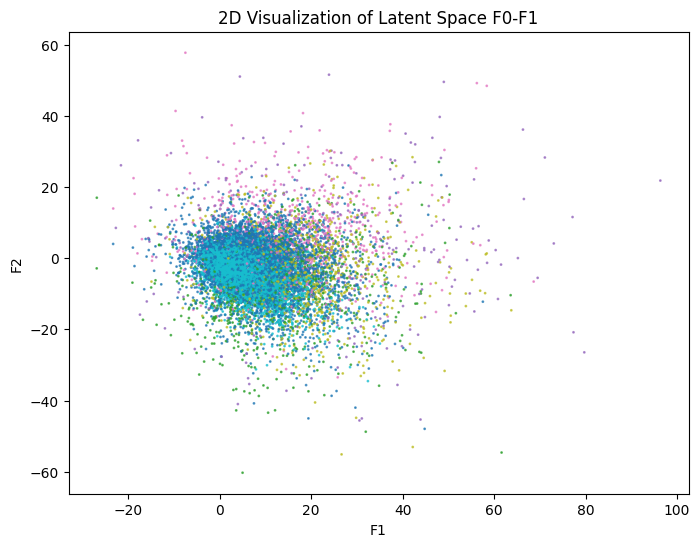

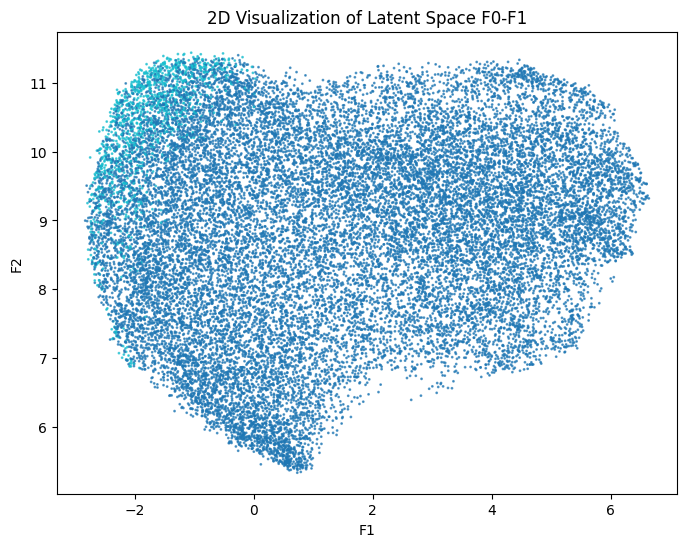

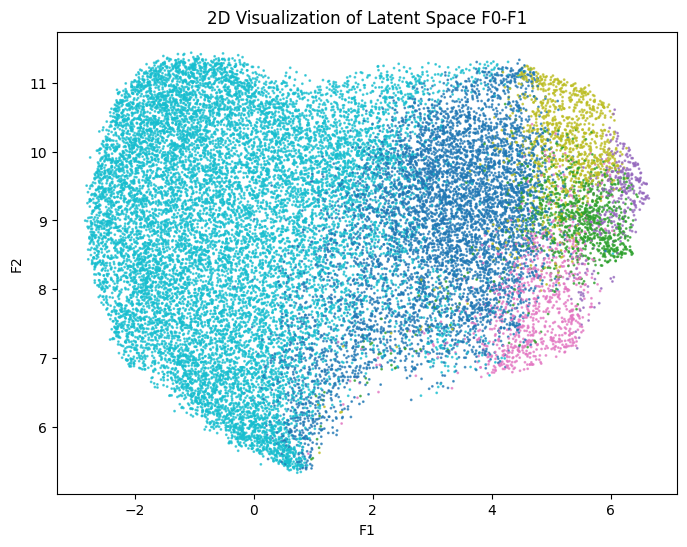

In [6]:
train_loss_across_latentdim = []
val_loss_across_latentdim = []

for  latent_dim in latent_dim_array:
        
    now = datetime.now()

    time_str = now.strftime("%Y%m%d_%H%M")

    result_dir = os.path.join('../results/', pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str)
    os.makedirs(result_dir, exist_ok=True)

    # Train AE
    ae = AE(latent_dim=latent_dim, input_ps=input_ps, BN_flag=BN_flag, dropout_flag=dropout_flag).to(device)

    ae, train_losses, val_losses = train_ae(ae, train_loader, val_loader, device, epochs=epochs, lr=lr, loss_norm_flag=loss_norm_flag, result_dir = result_dir)

    train_loss_across_latentdim.append(train_losses[-1])
    val_loss_across_latentdim.append(val_losses[-1])
    
    latents, images, group_id = dataloader_model_latents(ae, whole_data_loader, device)

    if isinstance(group_id, torch.Tensor):
        group_id = group_id.cpu().numpy()
    elif isinstance(group_id, list):
        group_id = torch.cat(group_id).cpu().numpy()

    latents_2d = UMAP_train(latents, result_dir)

    DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latents, eps=eps, min_samples=min_samples, result_dir=result_dir)

    kmeans, kmeans_labels = kmeans_cluster(latents, num_clusters=kmeans_num_clusters, result_dir=result_dir)

    fig = umap_2Dplot(latents_2d, 0,1,group_id)
    fig.savefig(os.path.join(result_dir, 'umap_2d_grouplabels.png'))

    fig = cluster_2Dplot(latents, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_latent01_labels.png'))
    
    fig = cluster_2Dplot(latents, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_latent01_labels.png'))

    fig = cluster_2Dplot(latents_2d, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_umap2d_labels.png'))
    
    fig = cluster_2Dplot(latents_2d, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_umap2d_labels.png'))


In [7]:
joblib.dump(train_loss_across_latentdim, os.path.join('../results', 'train_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
joblib.dump(val_loss_across_latentdim, os.path.join('../results', 'val_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
    

['../results/val_loss_across_latentdimpax_wholecell_norm_correctloader_ch1_ps32_latdim_24_20251007_1537.pkl']

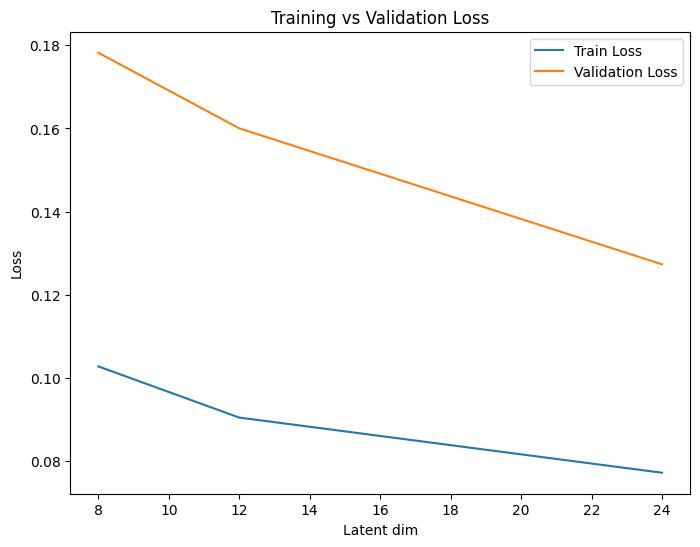

In [8]:
# Plot training and validation loss
fig = plt.figure(figsize=(8, 6))
plt.plot(latent_dim_array, train_loss_across_latentdim, label='Train Loss')
plt.plot(latent_dim_array, val_loss_across_latentdim, label='Validation Loss')
plt.xlabel('Latent dim')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
fig.savefig(os.path.join('../results', 'latent_dim_train_val_losses'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.png'))